In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


## Data Import & Clean

In [2]:
dfs = []
months = ["January 2025", "February 2025", "March 2025", "April 2024", "May 2024", "June 2024",
          "July 2024", "August 2024", "September 2024", "October 2024", "November 2024 corrected", "December 2024"]

for month in months:
    dfs.append(pd.read_excel(f"{month}.xlsx", dtype=str, keep_default_na=False))


In [3]:
all_calls_df = pd.concat(dfs, ignore_index=True)


## Finding Direct/Transferred Calls

In [28]:
# 5 intake numbers
numbers_names = {
    'Criminal Records': '13122296071',
    'HIV Intake VM': '13123478309',
    'legalclinics': '13124235938',
    'Veterans Rights Project VM': '13123478340',
    'Trafficking Survivors Assistance Project': '13122296073'
}

# Identify First Row of Each Call
first_rows = all_calls_df.groupby("Correlation ID").first().reset_index()

results = []

for label, number in numbers_names.items():
    # Total calls to this number 
    total = all_calls_df[all_calls_df["Called number"] == number]["Correlation ID"].nunique()

    # Direct calls - Called number in first row + TERMINATING + CallTower
    direct = first_rows[
        (first_rows["Called number"] == number) &
        (first_rows["Direction"] == "TERMINATING") &
        (first_rows["PSTN vendor name"] == "CallTower")
    ]["Correlation ID"].nunique()

    # Transferred calls = total - direct
    transferred = total - direct

    # Store results
    results.append({
        "Line": label,
        "Called Number": number,
        "Total Calls": total,
        "Direct Calls": direct,
        "Transferred Calls": transferred
    })

summary_df = pd.DataFrame(results)
summary_df


,Line,Called Number,Total Calls,Direct Calls,Transferred Calls
0,Criminal Records,13122296071,3195,64,3131
1,HIV Intake VM,13123478309,741,8,733
2,legalclinics,13124235938,20000,115,19885
3,Veterans Rights Project VM,13123478340,1757,83,1674
4,Trafficking Survivors Assistance Project,13122296073,102,1,101


## Bar plot to show results from previous table

                                   Category  Transfer Call %  Direct Call %
0                          Criminal Records        97.996870       2.003130
1                             HIV Intake VM        98.920378       1.079622
2                              legalclinics        99.425000       0.575000
3                Veterans Rights Project VM        95.276039       4.723961
4  Trafficking Survivors Assistance Project        99.019608       0.980392


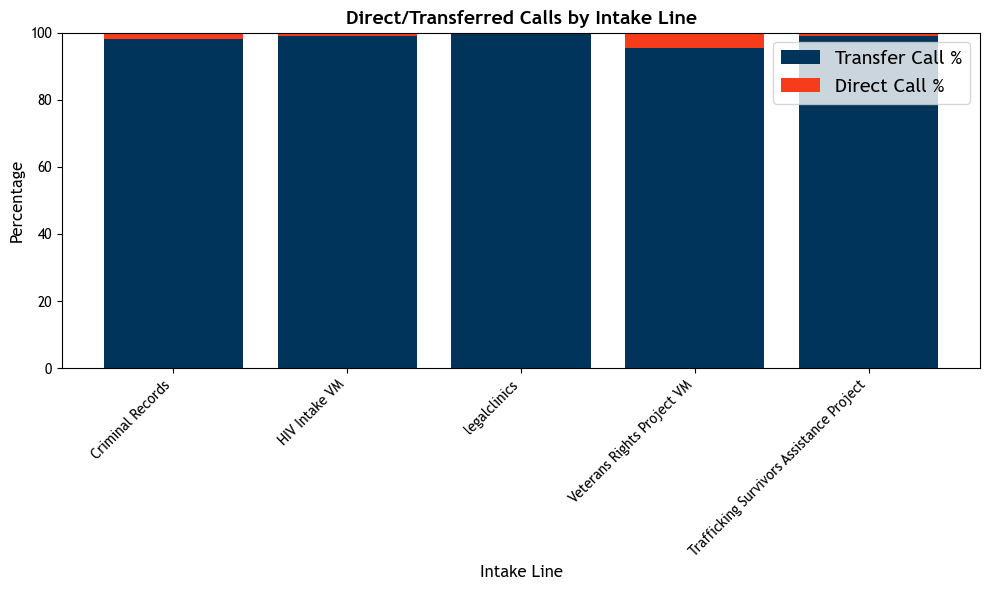

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Trebuchet MS'

summary_df = pd.DataFrame([
    {"Category": "Criminal Records", "Direct Calls": 64, "Transferred Calls": 3131},
    {"Category": "HIV Intake VM", "Direct Calls": 8, "Transferred Calls": 733},
    {"Category": "legalclinics", "Direct Calls": 115, "Transferred Calls": 19885},
    {"Category": "Veterans Rights Project VM", "Direct Calls": 83, "Transferred Calls": 1674},
    {"Category": "Trafficking Survivors Assistance Project", "Direct Calls": 1, "Transferred Calls": 101},
])

summary_df["Total"] = summary_df["Direct Calls"] + summary_df["Transferred Calls"]
summary_df["Direct Call %"] = (summary_df["Direct Calls"] / summary_df["Total"]) * 100
summary_df["Transfer Call %"] = (summary_df["Transferred Calls"] / summary_df["Total"]) * 100

print(summary_df[["Category", "Transfer Call %", "Direct Call %"]])

bar_width = 0.35
x = range(len(summary_df))

plt.figure(figsize=(10, 6))
plt.bar(x, summary_df["Transfer Call %"], label="Transfer Call %", color="#00345b")
plt.bar(x, summary_df["Direct Call %"], bottom=summary_df["Transfer Call %"], label="Direct Call %", color="#f73c1b")

plt.xlabel("Intake Line", fontsize=12)
plt.ylabel("Percentage", fontsize=12)
plt.title("Direct/Transferred Calls by Intake Line", fontsize=14, fontweight="bold")
plt.xticks(ticks=x, labels=summary_df["Category"], rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 100)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


## Finding total calls for all intake lines

In [27]:
import pandas as pd

number_name_map = {
    '13123478347': 'A2J Immigration',
    '18882652188': 'A2J Immigration Toll Free',
    '13124235904': 'Austin Intake VM',
    '13122296344': 'Bankruptcy Helpdesk VM',
    '13124235900': 'CLASP VM',
    '13122296071': 'Criminal Records',
    '13123478392': 'Education Law Referrals VM',
    '13124235909': 'Fair Housing Intake VM',
    '13123478309': 'HIV Intake VM',
    '13122296072': 'JEHD (Juvenile Expungement Help Desk)',
    '13124235938': 'legalclinics (Community Legal Clinics)',
    '13124312101': 'OP Appeals Project',
    '13123478340': 'Veterans Rights Project VM',
    '13122296073': 'Trafficking Survivors Assistance Project',
    '18004459025': 'Migrant Legal Assistance Program',
    '18884018200': 'Nursing Home Ombudsman',
    '13122296014': 'Markham Eviction Help Desk'
}

# Normalize 'Called number' column
all_calls_df['Called number'] = all_calls_df['Called number'].str.replace(r'\D', '', regex=True)
all_calls_df['Called number'] = all_calls_df['Called number'].apply(lambda x: f"1{x}" if len(x) == 10 else x)

# Filter and count total calls for each number
business_numbers = list(number_name_map.keys())

call_totals = (
    all_calls_df[all_calls_df['Called number'].isin(business_numbers)]
    .groupby('Called number')['Correlation ID']
    .nunique()
    .reset_index(name='Total Calls')
)

call_totals['Line Name'] = call_totals['Called number'].map(number_name_map)

# Reorder columns for clarity
call_totals = call_totals[['Line Name', 'Called number', 'Total Calls']].sort_values('Total Calls', ascending=False)

call_totals


,Line Name,Called number,Total Calls
12,legalclinics (Community Legal Clinics),13124235938,20000
4,Bankruptcy Helpdesk VM,13122296344,4503
1,Criminal Records,13122296071,3195
6,Veterans Rights Project VM,13123478340,1757
0,Markham Eviction Help Desk,13122296014,1101
10,Austin Intake VM,13124235904,1086
2,JEHD (Juvenile Expungement Help Desk),13122296072,1038
5,HIV Intake VM,13123478309,741
11,Fair Housing Intake VM,13124235909,123
9,CLASP VM,13124235900,106
